<a href="https://colab.research.google.com/github/MLuc123/DS3001-SP26/blob/main/assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

## Responses to Q1
1. A model is considered linear when the parameters are linear, not necessarily the coefficients. This means that the model is build by multiplying each feature by a constant parameter and adding them together. Parameters are never multiplied together
2. The trick is to interpret the coefficient revolves around the intercept. If the model includes an intercept we cannot include a dumy variable for every single category without disrupting the math, therefore we have to drop one category to serve as the baseline. The coefficient for any dummy variable represents the expected difference between the category and the baseline category.
3. No, a linear line extends infinitely meaning that the model will eventually predict impossible secenerios/probabilities.
4. Signs that your linear model is overfitting include a performance drop off where the model does not perform well on new data and inflated coefficients.
5. Multi colinearity occurs when two+ variables give the model redundant information which is explained by the two stage least squares technique (TSLSST). The TSLST says that if you try to predict one independent variable by using only the other IVs and get a perfect preciction it proves the isolated variable brings no new informaiton to teh table. These variables overlap completely and that causes the model to get confused about which variables is causing the changes which causes the standard errors to inflate.
6. We can inforporate non-linear relationships by transformign teh data features before feeding them into the algorithm. For example, we can add a squared version of a variable to help the model capture U shaped curves or take a log of a variable to handle exponential growth or heavily skewed data. We can also multiply two featuers together to create an interaction term which allows the model to understand if the effect of one variable changes depending on the value of another.
7. In an additive model the intercept represents out theoretical starting point when expected outcome of every single continuous variable is zero and all categorical variabels are at their hidden baseline. A slope coefficient represents the step size, telling us exactly how much teh predicted outcome changes when we increase a specific continous variable by one unit. A dummy variable coefficient represents the expected difference in the outcome between the specific category and the omitted baseline category.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


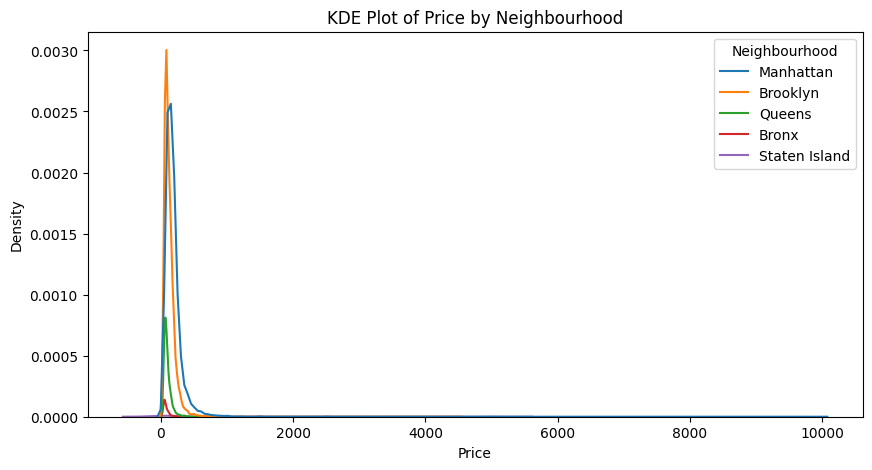

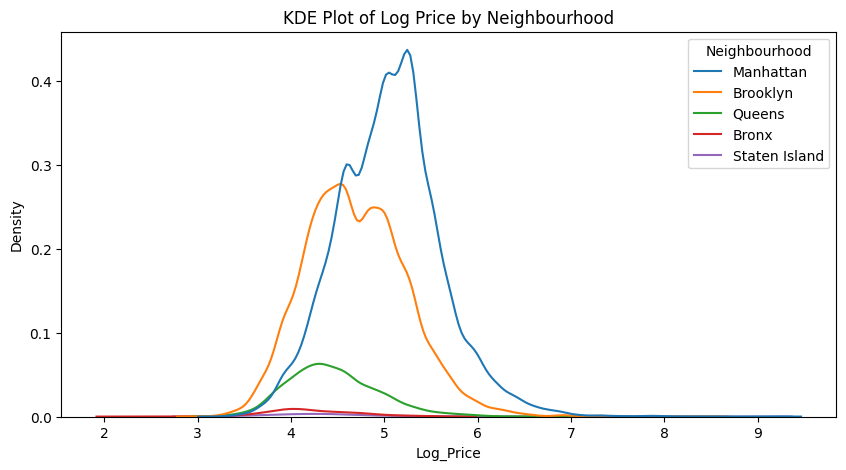

Coefficients without intercept:
Neighbourhood_Bronx: 75.28
Neighbourhood_Brooklyn: 127.75
Neighbourhood_Manhattan: 183.66
Neighbourhood_Queens: 96.86
Neighbourhood_Staten Island: 146.17
Intercept (Baseline Category): 75.28

Coefficients with intercept:
Neighbourhood_Brooklyn: 52.47
Neighbourhood_Manhattan: 108.39
Neighbourhood_Queens: 21.58
Neighbourhood_Staten Island: 70.89
R-squared: 0.0459
RMSE: 140.92
Review Scores Coefficient: 1.21
R-squared: 0.0542
RMSE: 140.30
New Review Scores Coefficient: 1.20
Interaction R-squared: 0.0546
Interaction RMSE: 140.28


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv('/content/drive/MyDrive/Q1_clean.csv')
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})

averages = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print(averages)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood')
plt.title('KDE Plot of Price by Neighbourhood')
plt.show()
df['Log_Price'] = np.log(df['Price'] + 1)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Log_Price', hue='Neighbourhood')
plt.title('KDE Plot of Log Price by Neighbourhood')
plt.show()


X_part2 = pd.get_dummies(df[['Neighbourhood']])
y = df['Price']
model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(X_part2, y)
print("Coefficients without intercept:")
for col, coef in zip(X_part2.columns, model_no_intercept.coef_):
    print(f"{col}: {coef:.2f}")

X_part3 = pd.get_dummies(df[['Neighbourhood']], drop_first=True)
model_intercept = LinearRegression(fit_intercept=True)
model_intercept.fit(X_part3, y)
print(f"Intercept (Baseline Category): {model_intercept.intercept_:.2f}")
print("\nCoefficients with intercept:")
for col, coef in zip(X_part3.columns, model_intercept.coef_):
    print(f"{col}: {coef:.2f}")

X = df[['Review Scores Rating', 'Neighbourhood']]
X = pd.get_dummies(X, drop_first=True)

X = X.fillna(X.median())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model_part4 = LinearRegression()
model_part4.fit(X_train, y_train)
y_pred = model_part4.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
review_coef_index = list(X.columns).index('Review Scores Rating')
print(f"Review Scores Coefficient: {model_part4.coef_[review_coef_index]:.2f}")



X = df[['Review Scores Rating', 'Neighbourhood', 'Property Type']]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model_part5 = LinearRegression()
model_part5.fit(X_train, y_train)
y_pred = model_part5.predict(X_test)
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
review_coef_index = list(X.columns).index('Review Scores Rating')
print(f"New Review Scores Coefficient: {model_part5.coef_[review_coef_index]:.2f}")


df['Interaction'] = df['Neighbourhood'] + " - " + df['Property Type']
X_interact = df[['Review Scores Rating', 'Interaction']]
X_interact = pd.get_dummies(X_interact, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_interact, y, test_size=0.20, random_state=42)

model_interact = LinearRegression()
model_interact.fit(X_train, y_train)

y_pred = model_interact.predict(X_test)
print(f"Interaction R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Interaction RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Concept Question:
If the coefficient on review scores rating changes from part 4 to part 5 it means that the part 4 model had omitted variable bias. In other words, in part four the review score was taking the blame for the effect of the missing property type and in Part 5 by including the property type the review score coefficient shows teh true effect of a rating increase while holding the physical property perfectly constant.

### Are the coefficints just the sum of part 5
No, the coefficients capture the synergetic effect. They catch the extra premiums that many of the properities may have.



**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

               count          mean           std        min        25%  \
Make                                                                     
Chevrolet        6.0  4.535000e+05  2.466064e+05   267000.0   288500.0   
Datsun           3.0  2.896667e+05  1.050397e+04   279000.0   284500.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  2.160199e+05   237000.0   411000.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Renault         68.0  6.625735e+05  2.

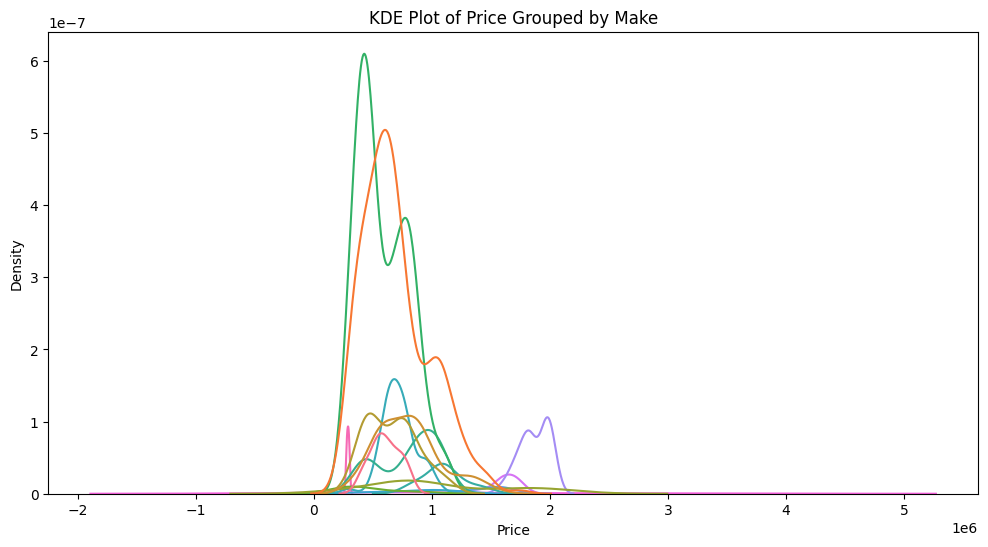


Model 1 (Numeric) Test R2: 0.4000
Model 2 (Categorical) Test R2: 0.6457
Model 3 (Joint) Test R2: 0.8186

Testing Polynomial Degrees:
Degree 1 Test R2: 0.8186
Degree 2 Test R2: 0.8208
Degree 3 Test R2: 0.8186
Degree 4 Test R2: 0.8130


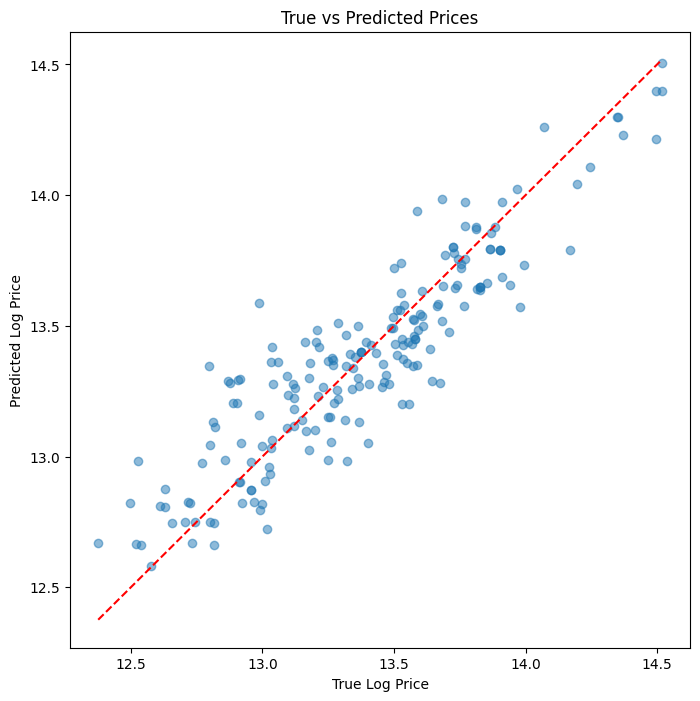

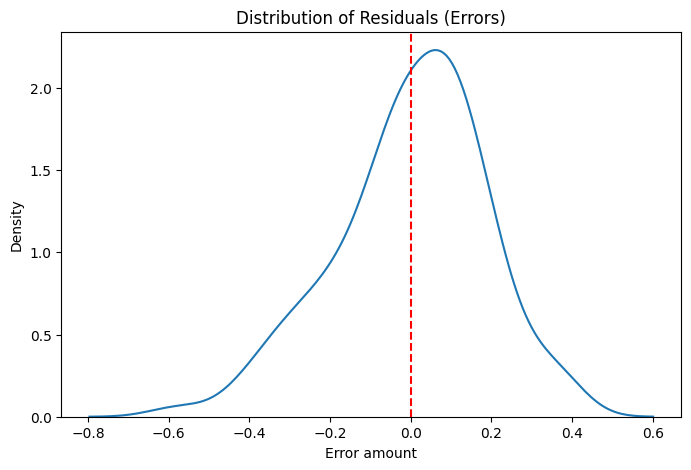

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

df = pd.read_csv('/content/drive/MyDrive/cars_hw.csv')
df['Log_Price'] = np.log(df['Price'] + 1)
df['Log_Mileage'] = np.log(df['Mileage_Run'] + 1)

print(df.groupby('Make')['Price'].describe())

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Price', hue='Make', legend=False)
plt.title('KDE Plot of Price Grouped by Make')
plt.show()

y = df['Log_Price']
X_num = df[['Make_Year', 'Log_Mileage', 'Seating_Capacity']]
X_cat = pd.get_dummies(df[['Body_Type', 'Make', 'Fuel_Type', 'Transmission', 'Transmission_Type']], drop_first=True)
X_joint = pd.concat([X_num, X_cat], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.20, random_state=42)
mod1 = LinearRegression().fit(X_train, y_train)
print(f"\nModel 1 (Numeric) Test R2: {r2_score(y_test, mod1.predict(X_test)):.4f}")

X_train, X_test, y_train, y_test = train_test_split(X_cat, y, test_size=0.20, random_state=42)
mod2 = LinearRegression().fit(X_train, y_train)
print(f"Model 2 (Categorical) Test R2: {r2_score(y_test, mod2.predict(X_test)):.4f}")

X_train, X_test_joint, y_train, y_test = train_test_split(X_joint, y, test_size=0.20, random_state=42)
mod3 = LinearRegression().fit(X_train, y_train)
print(f"Model 3 (Joint) Test R2: {r2_score(y_test, mod3.predict(X_test_joint)):.4f}")

print("\nTesting Polynomial Degrees:")
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_num_poly = pd.DataFrame(poly.fit_transform(X_num))

    X_poly_joint = pd.concat([X_num_poly, X_cat.reset_index(drop=True)], axis=1)

    X_poly_joint.columns = X_poly_joint.columns.astype(str)

    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly_joint, y, test_size=0.20, random_state=42)
    mod_poly = LinearRegression().fit(X_train_p, y_train_p)

    print(f"Degree {degree} Test R2: {r2_score(y_test_p, mod_poly.predict(X_test_p)):.4f}")

y_pred_best = mod3.predict(X_test_joint)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('True Log Price')
plt.ylabel('Predicted Log Price')
plt.title('True vs Predicted Prices')
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(y_test - y_pred_best)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error amount')
plt.show()

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

[Click Here for images of questions 1-6 mathematical calculations ](https://drive.google.com/drive/folders/1LCuGoNtLF0u8g4BRgD2s2jMjcZjyCEa1?usp=share_link)

# The intuition of my discovery:
To find the best model weights, the algorithm calculates b=A^-1*C. Vector C measures how strongly each feature affects the target variable. Because features often overlap and share the same information, the model multiplies by the inverse of Matrix A to  take that redundancy. This ensures each feature is only weighted for its contribution to the final prediction.